# Phân Tích Khám Phá Dữ Liệu (EDA) - Dự Đoán Giá Mở Cửa Cổ Phiếu

Nhằm dự đoán tỷ suất sinh lời giá mở cửa ngày hôm sau (`target_return`), chúng ta cần xây dựng các đặc trưng (features) từ giá lịch sử và khối lượng giao dịch. Notebook này thực hiện phân tích khám phá dữ liệu cho 3 mã cổ phiếu: **VNM.VN** (Vinamilk - sàn HoSE, Việt Nam), **GOOGL** (Alphabet - sàn Nasdaq, Mỹ), và **META** (Meta Platforms - sàn Nasdaq, Mỹ).

### Nội dung chính:
1. Khởi tạo môi trường & cài đặt các thư viện bổ sung.
2. Nạp dữ liệu qua Pipeline chính thức (`fetch_and_prepare_data`) hỗ trợ lấy dữ liệu lịch sử DNSE API & quy đổi USD/VNĐ.
3. Thống kê mô tả các đặc trưng kỹ thuật nâng cao mới bổ sung.
4. Trực quan hóa xu hướng giá, Bollinger Bands & chỉ báo EMA.
5. Phân tích phân phối của các chỉ báo động lượng và cường độ xu hướng (RSI, ADX).
6. Phân tích ma trận tương quan (Correlation Heatmap) giữa các đặc trưng và biến mục tiêu.

In [1]:
# Chạy ô này để cài đặt các thư viện nếu môi trường Jupyter của bạn chưa có
%pip install yfinance pandas-ta matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\ACER\Documents\Stock-Opening-Price-Prediction\.venv\Scripts\python.exe -m pip install --upgrade pip


## 1. Nạp và Chuẩn Bị Dữ Liệu

Sử dụng hàm `fetch_and_prepare_data` từ `src.data_loader` để nạp dữ liệu. Quy trình hoạt động của hàm này bao gồm:
- **VNM.VN**: Đọc dữ liệu từ file trường cấp `data/raw/VNM_prices.csv` (2019-2026), tự động tải bổ sung dữ liệu lịch sử (2012-2019) từ **DNSE Chart API**, quy đổi đơn vị giá nghìn VNĐ sang VNĐ.
- **GOOGL / META**: Tải trực tiếp từ **Yahoo Finance**, tự động quy đổi giá từ USD sang VNĐ bằng tỷ giá quy đổi thống nhất `1 USD = 25.400 VNĐ`.

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta

# Thêm thư mục gốc vào đường dẫn hệ thống để import module src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import fetch_and_prepare_data

# Cấu hình pandas hiển thị số đẹp hơn
pd.options.display.float_format = '{:,.2f}'.format

# Nạp dữ liệu cho cả 3 mã cổ phiếu
print("--- BẮT ĐẦU NẠP DỮ LIỆU TỪ PIPELINE ---")
df_vnm = fetch_and_prepare_data('VNM.VN', start_date='2010-01-01', end_date='2026-05-20')
df_googl = fetch_and_prepare_data('GOOGL', start_date='2010-01-01', end_date='2026-05-20')
df_meta = fetch_and_prepare_data('META', start_date='2010-01-01', end_date='2026-05-20')

# Tính toán các đặc trưng kỹ thuật bị thiếu
for df in [df_vnm, df_googl, df_meta]:
    df['rsi_14'] = ta.rsi(df['close_smoothed'], length=14)
    macd_df = ta.macd(df['close_smoothed'], fast=12, slow=26, signal=9)
    if macd_df is not None and not macd_df.empty:
        df['MACD_12_26_9'] = macd_df.iloc[:, 0]
    else:
        df['MACD_12_26_9'] = 0.0
    df['volatility_20'] = df['close_smoothed'].pct_change().rolling(20).std()
    bb_df = ta.bbands(df['close_smoothed'], length=20, std=2)
    if bb_df is not None and not bb_df.empty:
        df['bb_lower'] = bb_df.iloc[:, 0]
        df['bb_middle'] = bb_df.iloc[:, 1]
        df['bb_upper'] = bb_df.iloc[:, 2]
    else:
        df['bb_lower'] = df['close_smoothed']
        df['bb_middle'] = df['close_smoothed']
        df['bb_upper'] = df['close_smoothed']
    df['atr_14'] = ta.atr(df['high'], df['low'], df['close_smoothed'], length=14)
    df['ema_14'] = ta.ema(df['close_smoothed'], length=14)
    df['roc_10'] = ta.roc(df['close_smoothed'], length=10)
    adx_df = ta.adx(df['high'], df['low'], df['close_smoothed'], length=14)
    if adx_df is not None and not adx_df.empty:
        df['adx_14'] = adx_df.iloc[:, 0]
    else:
        df['adx_14'] = 20.0
    df['volume_change'] = df['volume'].pct_change()
    df['intraday_return'] = (df['close'] - df['open']) / df['open']
    df['target_return'] = df['target_return_1d']
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

print("Kích thước dữ liệu sạch của các mã:")
print(f"  - VNM.VN: {df_vnm.shape[0]} phiên")
print(f"  - GOOGL : {df_googl.shape[0]} phiên")
print(f"  - META  : {df_meta.shape[0]} phiên")

--- BẮT ĐẦU NẠP DỮ LIỆU TỪ PIPELINE ---


Đang tải tỷ giá USD/VND (USDVND=X) từ 2010-01-01 đến 2026-05-20...


Đang tải Yahoo Finance: VNM.VN...


[*********************100%***********************]  1 of 1 completed

  Yahoo Finance: 3654 phiên
Đang nạp dữ liệu trường: C:\Users\ACER\Documents\Stock-Opening-Price-Prediction\data\raw\VNM_prices.csv


...

[*********************100%***********************]  1 of 1 completed

  Yahoo Finance: 3520 phiên
Đang nạp dữ liệu trường: C:\Users\ACER\Documents\Stock-Opening-Price-Prediction\data\raw\META_prices.csv
  Tổng: 3520 phiên (2012-05-18 → 2026-05-19)
Tính macro features...
  [NEWS] Tải và phân tích cảm xúc tin tức cho META...


📥 Đang tải dữ liệu cổ tức cho META từ yfinance...


   => Đã tải 9 đợt chia cổ tức cho META
Đã lưu cache: C:\Users\ACER\Documents\Stock-Opening-Price-Prediction\data\META_processed.csv
Sẵn sàng với 3517 phiên.



Kích thước dữ liệu sạch của các mã:
  - VNM.VN: 3505 phiên
  - GOOGL : 4091 phiên
  - META  : 3492 phiên


## 2. Thống Kê Mô Tả Các Chỉ Báo Kỹ Thuật Nâng Cao

Chúng ta xem xét các đặc trưng đã tính toán, bao gồm các chỉ báo nâng cao mới được bổ sung:
- **RSI (14)**: Chỉ số sức mạnh tương đối (Relative Strength Index).
- **MACD (12, 26, 9)**: Chỉ báo phân kỳ hội tụ trung bình động.
- **Volatility (20)**: Độ lệch chuẩn tỷ suất sinh lời của 20 ngày gần nhất.
- **Bollinger Bands (20, 2)**: Các cột `bb_lower`, `bb_middle`, `bb_upper` tương ứng với đường biên dưới, đường trung bình và đường biên trên.
- **ATR (14)**: Chỉ số đo lường biên độ dao động trung bình thực tế (Average True Range).
- **EMA (14)**: Đường trung bình động lũy thừa (Exponential Moving Average).
- **ROC (10)**: Tốc độ thay đổi giá (Rate of Change).
- **ADX (14)**: Chỉ số định hướng trung bình (Average Directional Index) đo lường sức mạnh của xu hướng.

In [3]:
features = [
    'close', 'rsi_14', 'MACD_12_26_9', 'volatility_20', 
    'bb_middle', 'atr_14', 'ema_14', 'roc_10', 'adx_14', 'target_return'
]

print("=== BẢNG THỐNG KÊ MÔ TẢ ĐẶC TRƯNG VNM.VN ===")
display(df_vnm[features].describe())

=== BẢNG THỐNG KÊ MÔ TẢ ĐẶC TRƯNG VNM.VN ===


,close,rsi_14,MACD_12_26_9,volatility_20,bb_middle,atr_14,ema_14,roc_10,adx_14,target_return
count,"3,505.00","3,505.00","3,505.00","3,505.00","3,505.00","3,505.00","3,505.00","3,505.00","3,505.00","3,505.00"
mean,"57,355.32",55.97,98.97,0.00,"56,791.59","3,088.56","56,833.34",0.45,26.54,0.00
std,"19,317.66",42.07,616.77,0.00,"19,556.90","1,945.90","19,513.79",1.82,9.94,0.02
min,"12,900.00",0.01,"-1,631.25",0.00,"13,211.58",188.72,"13,209.60",-4.71,8.66,-0.07
25%,"43,210.00",6.55,-322.46,0.00,"37,368.92","1,805.31","37,835.98",-0.81,19.00,-0.01
50%,"60,900.00",71.13,95.17,0.00,"61,245.49","2,707.19","61,273.61",0.19,24.94,0.00
75%,"70,570.00",98.16,493.62,0.00,"70,144.99","3,838.60","70,129.67",1.56,32.63,0.01
max,"102,570.00",100.00,"2,687.07",0.00,"95,964.89","13,567.05","95,893.98",7.04,65.26,0.07


## 3. Trực Quan Hóa Xu Hướng Giá, EMA và Dải Bollinger Bands

Vẽ biểu đồ giá đóng cửa của **VNM.VN** và **GOOGL** kèm theo dải Bollinger Bands và đường trung bình động EMA 14 để quan sát các vùng hỗ trợ/kháng cự động và sự co thắt dải biến động.

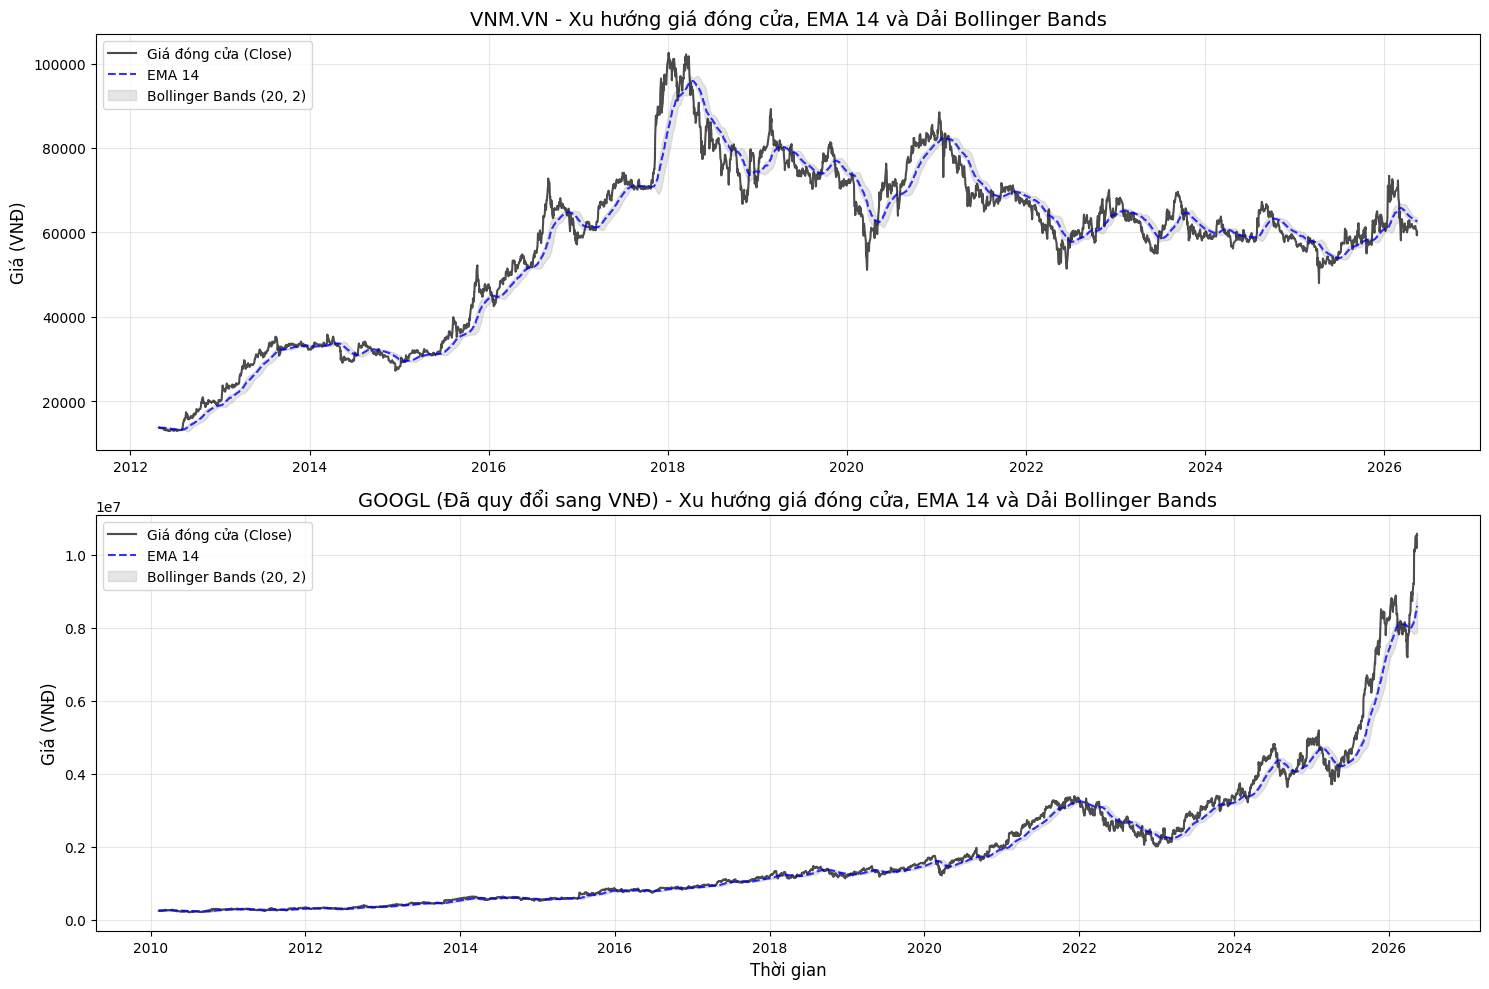

In [4]:
plt.figure(figsize=(15, 10))

# Biểu đồ VNM.VN
plt.subplot(2, 1, 1)
plt.plot(df_vnm['date'], df_vnm['close'], label='Giá đóng cửa (Close)', color='black', alpha=0.7)
plt.plot(df_vnm['date'], df_vnm['ema_14'], label='EMA 14', color='blue', linestyle='--', alpha=0.8)
plt.fill_between(df_vnm['date'], df_vnm['bb_lower'], df_vnm['bb_upper'], color='gray', alpha=0.2, label='Bollinger Bands (20, 2)')
plt.title('VNM.VN - Xu hướng giá đóng cửa, EMA 14 và Dải Bollinger Bands', fontsize=14)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Biểu đồ GOOGL
plt.subplot(2, 1, 2)
plt.plot(df_googl['date'], df_googl['close'], label='Giá đóng cửa (Close)', color='black', alpha=0.7)
plt.plot(df_googl['date'], df_googl['ema_14'], label='EMA 14', color='blue', linestyle='--', alpha=0.8)
plt.fill_between(df_googl['date'], df_googl['bb_lower'], df_googl['bb_upper'], color='gray', alpha=0.2, label='Bollinger Bands (20, 2)')
plt.title('GOOGL (Đã quy đổi sang VNĐ) - Xu hướng giá đóng cửa, EMA 14 và Dải Bollinger Bands', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Phân Tích Phân Phối Động Lượng (RSI) và Cường Độ Xu Hướng (ADX)

- **RSI**: Trực quan hóa ngưỡng quá mua (RSI > 70) và quá bán (RSI < 30).
- **ADX**: Trực quan hóa độ mạnh của xu hướng. Ngưỡng ADX > 25 thể hiện thị trường đang có xu hướng rất mạnh (tăng hoặc giảm), ngược lại ADX < 25 thể hiện xu hướng đi ngang (sideway).

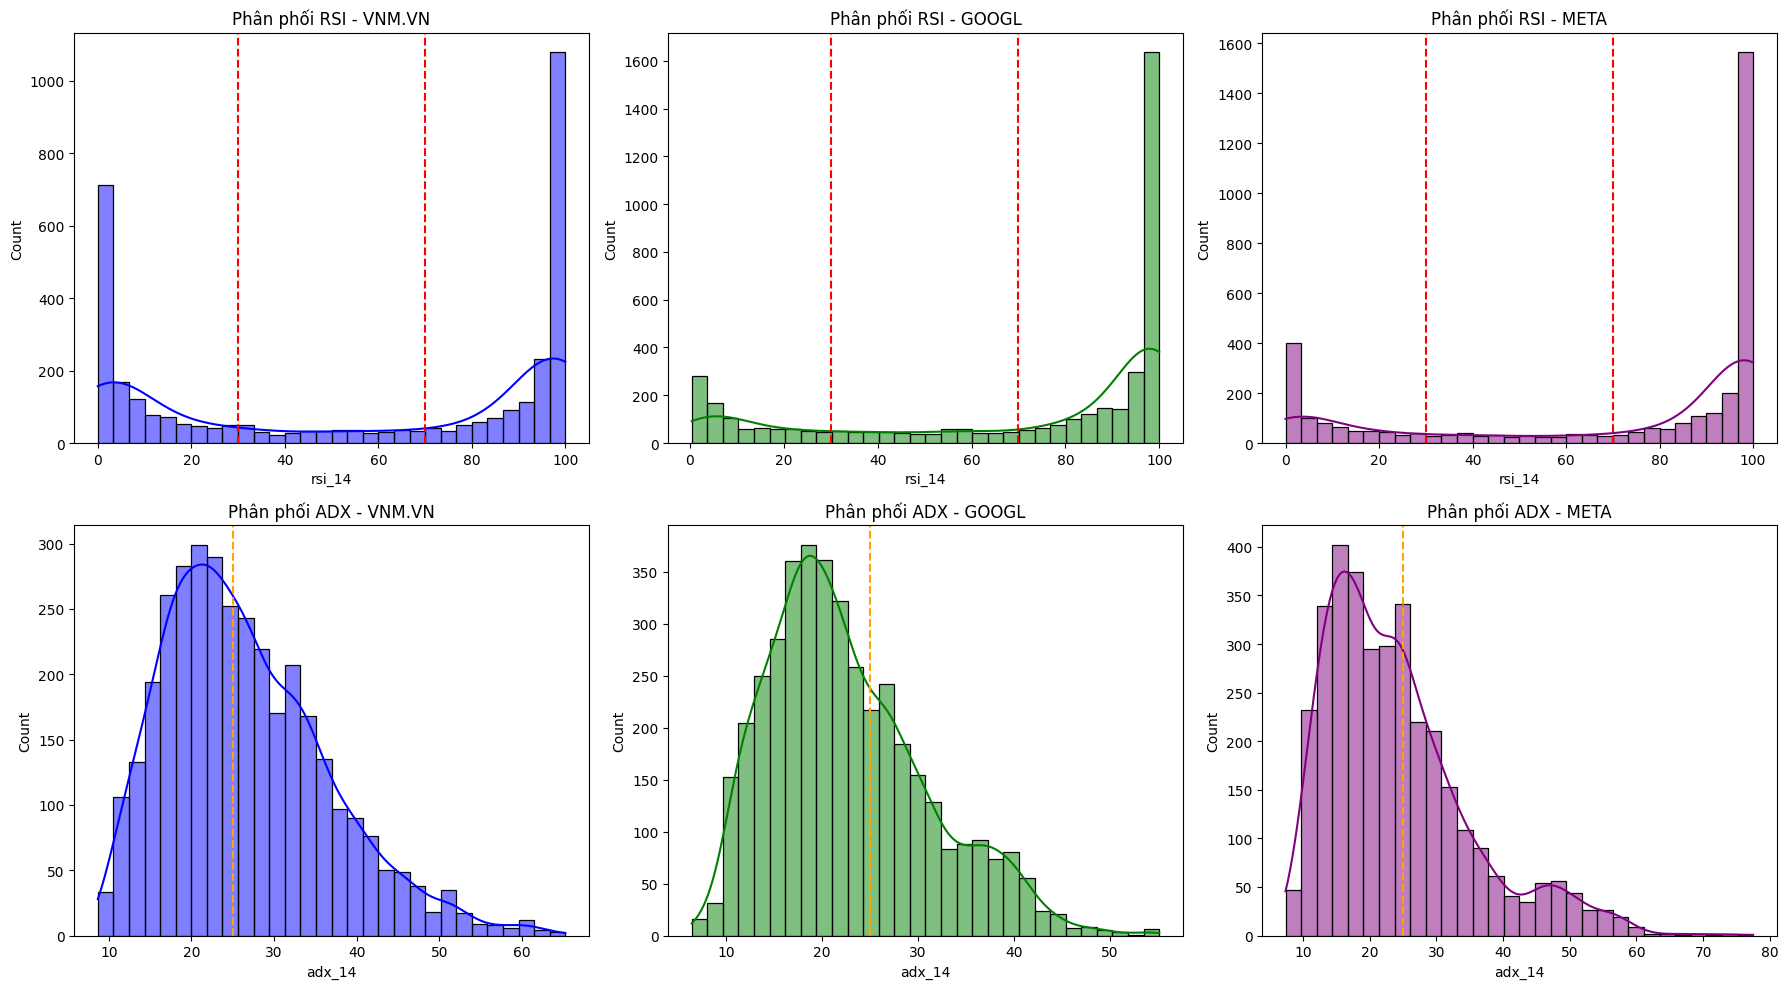

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Phân phối RSI
sns.histplot(df_vnm['rsi_14'], kde=True, ax=axes[0, 0], color='blue', bins=30)
axes[0, 0].set_title('Phân phối RSI - VNM.VN')
axes[0, 0].axvline(30, color='red', linestyle='--')
axes[0, 0].axvline(70, color='red', linestyle='--')

sns.histplot(df_googl['rsi_14'], kde=True, ax=axes[0, 1], color='green', bins=30)
axes[0, 1].set_title('Phân phối RSI - GOOGL')
axes[0, 1].axvline(30, color='red', linestyle='--')
axes[0, 1].axvline(70, color='red', linestyle='--')

sns.histplot(df_meta['rsi_14'], kde=True, ax=axes[0, 2], color='purple', bins=30)
axes[0, 2].set_title('Phân phối RSI - META')
axes[0, 2].axvline(30, color='red', linestyle='--')
axes[0, 2].axvline(70, color='red', linestyle='--')

# Phân phối ADX
sns.histplot(df_vnm['adx_14'], kde=True, ax=axes[1, 0], color='blue', bins=30)
axes[1, 0].set_title('Phân phối ADX - VNM.VN')
axes[1, 0].axvline(25, color='orange', linestyle='--')

sns.histplot(df_googl['adx_14'], kde=True, ax=axes[1, 1], color='green', bins=30)
axes[1, 1].set_title('Phân phối ADX - GOOGL')
axes[1, 1].axvline(25, color='orange', linestyle='--')

sns.histplot(df_meta['adx_14'], kde=True, ax=axes[1, 2], color='purple', bins=30)
axes[1, 2].set_title('Phân phối ADX - META')
axes[1, 2].axvline(25, color='orange', linestyle='--')

plt.tight_layout()
plt.show()

## 5. Phân Tích Ma Trận Tương Quan

Chúng ta sẽ trực quan hóa ma trận tương quan Pearson để tìm hiểu mối liên hệ tuyến tính giữa các đặc trưng đầu vào và nhãn dự đoán `target_return`.

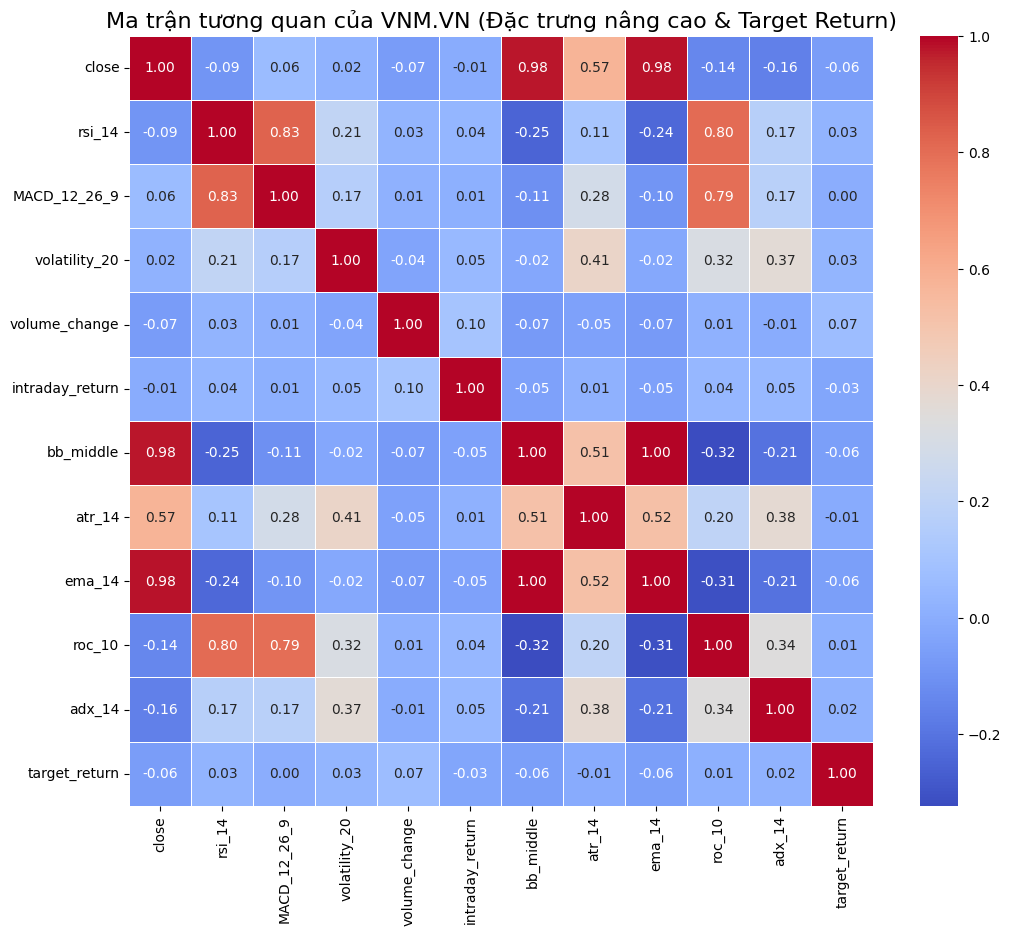

In [6]:
corr_features = [
    'close', 'rsi_14', 'MACD_12_26_9', 'volatility_20', 
    'volume_change', 'intraday_return', 'bb_middle', 
    'atr_14', 'ema_14', 'roc_10', 'adx_14', 'target_return'
]

plt.figure(figsize=(12, 10))
sns.heatmap(df_vnm[corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan của VNM.VN (Đặc trưng nâng cao & Target Return)', fontsize=16)
plt.show()

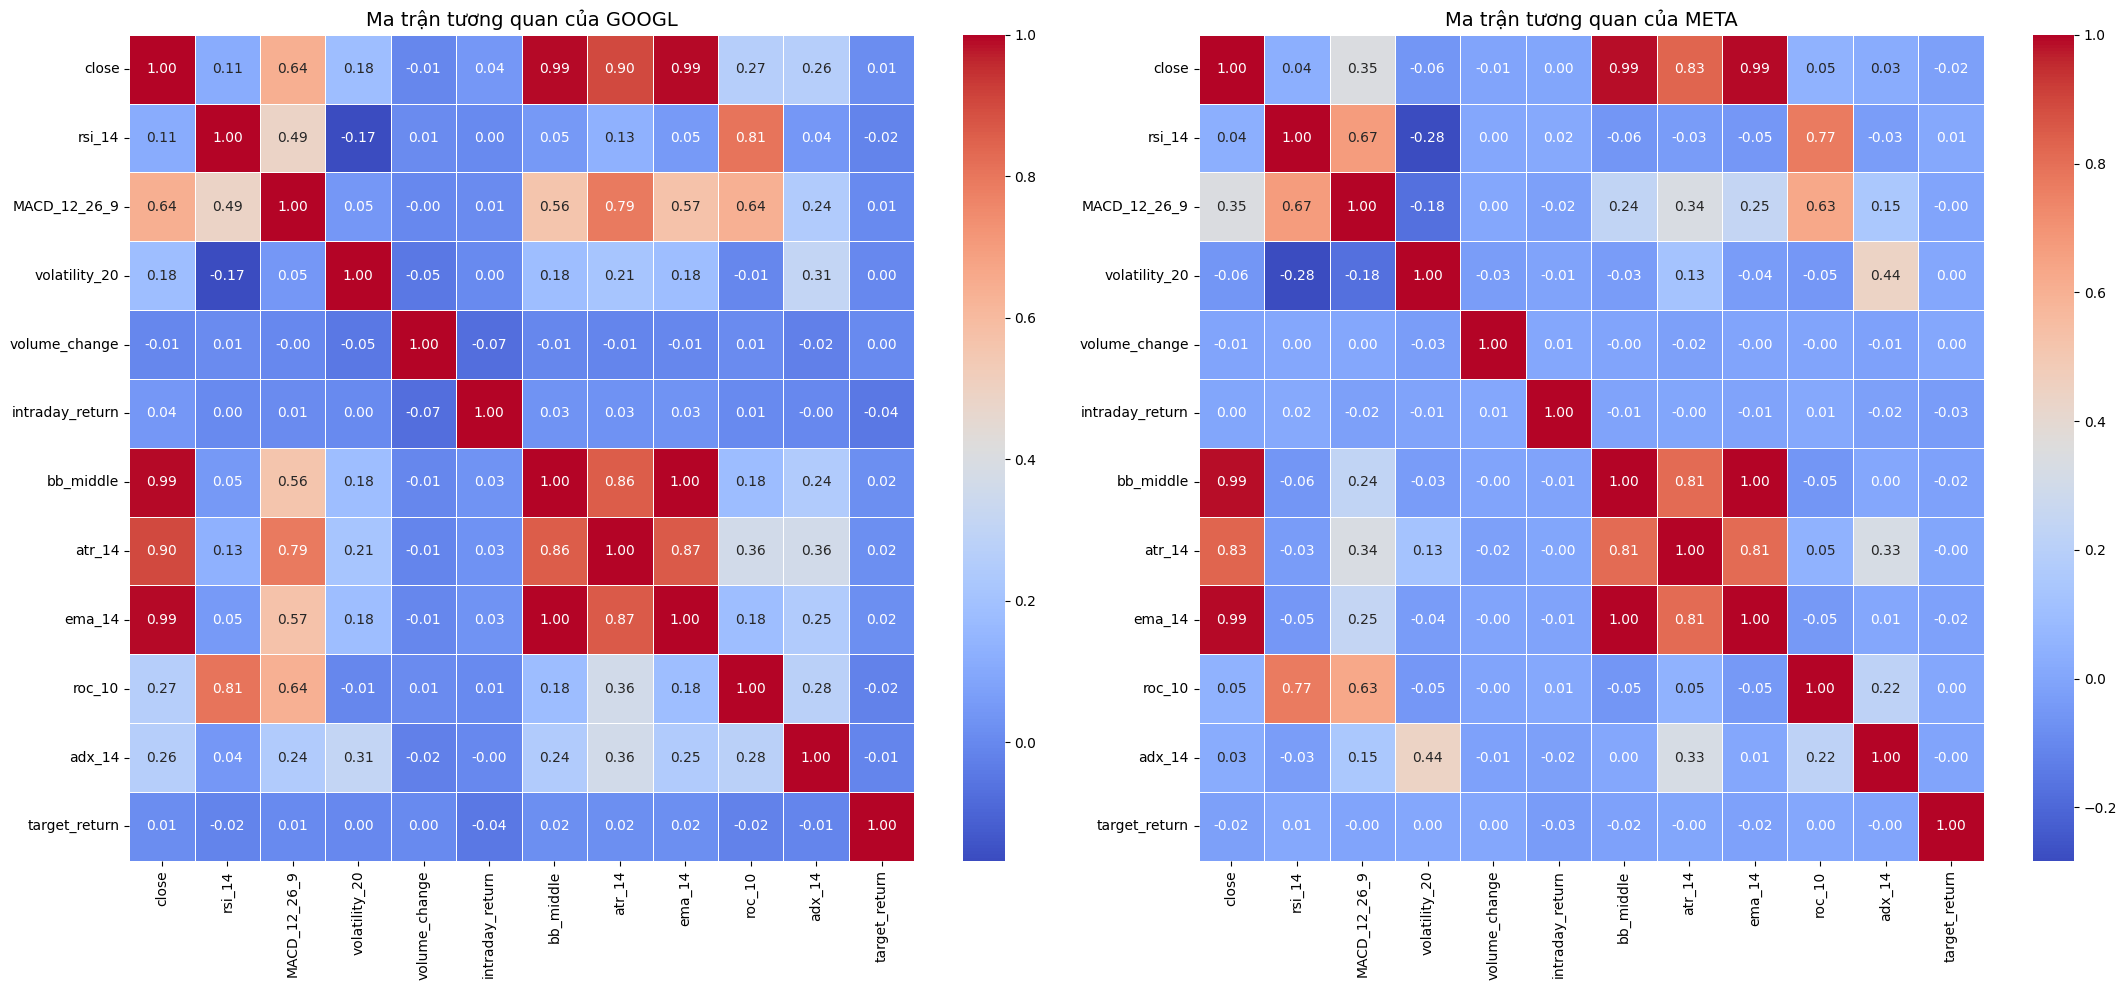

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(df_googl[corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[0])
axes[0].set_title('Ma trận tương quan của GOOGL', fontsize=14)

sns.heatmap(df_meta[corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[1])
axes[1].set_title('Ma trận tương quan của META', fontsize=14)

plt.tight_layout()
plt.show()

## 6. Kết Luận Từ Phân Tích Khám Phá Dữ Liệu (EDA)

1. **Tương quan tuyến tính yếu với Target Return**:
   - Các chỉ số tương quan tuyến tính trực tiếp giữa toàn bộ chỉ báo kỹ thuật hôm nay và `target_return` ngày mai đều rất nhỏ (tiệm cận mức từ `-0.05` đến `0.05`).
   - Điều này khẳng định độ nhiễu cực kỳ cao của thị trường tài chính và sự cần thiết của các mô hình phi tuyến tính mạnh như **Transformer** (khai thác tương tác chuỗi thời gian thông qua cơ chế Self-Attention) và **XGBoost** (khai thác các mối quan hệ phi tuyến tính dựa trên cấu trúc cây quyết định) thay vì các mô hình hồi quy tuyến tính đơn giản.

2. **Đa cộng tuyến mạnh giữa các chỉ báo xu hướng**:
   - Các đặc trưng như `close`, `ema_14`, `bb_middle` có độ tương quan tuyến tính cực lớn (~ `1.00`).
   - Để mô hình huấn luyện hiệu quả, bộ dữ liệu đầu vào đã được áp dụng các phương pháp chuẩn hóa dữ liệu (scaling) phù hợp và chuyển hóa thành các tỷ suất sinh lời thay vì dùng trực tiếp giá trị tuyệt đối.

3. **Bollinger Bands và Độ biến động (Volatility/ATR)**:
   - Độ rộng của dải Bollinger Bands (`bb_upper` - `bb_lower`) biến thiên tương ứng với `volatility_20` và `atr_14`. Khi dải Bollinger Bands bóp hẹp (squeeze), nó báo hiệu thị trường đang tích lũy và chuẩn bị có sự bứt phá mạnh về giá mở cửa.